# Proyecto 1
Alina Carías (22539) y Ariela Mishaan (22052)

## Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

## Carga de archivos

In [3]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path('/Users/arielamishaancohen/Documentos/Datasets gigantes/Ecobici')
files = sorted(DATA_DIR.glob('*.csv'))

COLS = [
    'Genero_Usuario', 'Edad_Usuario', 'Bici',
    'Ciclo_Estacion_Retiro', 'Fecha_Retiro', 'Hora_Retiro',
    'Ciclo_EstacionArribo', 'Fecha_Arribo', 'Hora_Arribo'
]

dfs = []
errores = []

for f in files:
    try:
        tmp = pd.read_csv(
            f,
            usecols=range(9), # solo las primeras 9 columnas
            names=COLS,
            header=0,
            on_bad_lines='skip',  
            engine='python'
        )
        tmp['_archivo'] = f.name # rastrear el origen
        dfs.append(tmp)
        print(f"OK  {f.name:45s} → {len(tmp):>8,} filas")
    except Exception as e:
        errores.append((f.name, str(e)))
        print(f"ERR {f.name}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"\nDataset combinado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Archivos cargados: {len(dfs)} / {len(files)}")
if errores:
    print(f"\nArchivos con error: {errores}")

OK  2024-01.csv                                   → 1,467,594 filas
OK  2024-02.csv                                   → 1,557,176 filas
OK  2024-03.csv                                   → 1,829,763 filas
OK  2024-04.csv                                   → 1,961,633 filas
OK  2024-05.csv                                   → 1,513,369 filas
OK  2024-06.csv                                   → 1,893,520 filas
OK  2024-07.csv                                   → 1,065,474 filas
OK  2024-08.csv                                   → 1,513,016 filas
OK  2024-09.csv                                   → 1,852,179 filas
OK  2024-10.csv                                   → 2,054,609 filas
OK  2024-11.csv                                   → 1,942,474 filas
OK  2024-12.csv                                   → 1,680,650 filas
OK  2025-01.csv                                   → 1,809,775 filas
OK  2025-02.csv                                   → 1,745,620 filas
OK  2025-03.csv                                 

## Limpieza

In [4]:
df['Fecha_Retiro'] = pd.to_datetime(df['Fecha_Retiro'], dayfirst=True, errors='coerce')
df['Fecha_Arribo'] = pd.to_datetime(df['Fecha_Arribo'], dayfirst=True, errors='coerce')

# combinar fecha + hora en datetime completo
df['dt_retiro'] = pd.to_datetime(
    df['Fecha_Retiro'].dt.strftime('%Y-%m-%d') + ' ' + df['Hora_Retiro'].astype(str),
    errors='coerce'
)
df['dt_arribo'] = pd.to_datetime(
    df['Fecha_Arribo'].dt.strftime('%Y-%m-%d') + ' ' + df['Hora_Arribo'].astype(str),
    errors='coerce'
)

In [5]:
# duración del viaje en minutos
df['duracion_min'] = (df['dt_arribo'] - df['dt_retiro']).dt.total_seconds() / 60

# variables temporales útiles
df['anio']          = df['dt_retiro'].dt.year
df['mes']           = df['dt_retiro'].dt.month
df['dia_semana']    = df['dt_retiro'].dt.day_name()
df['hora_retiro']   = df['dt_retiro'].dt.hour

# viaje circular: retiro == arribo
df['es_circular'] = (
    df['Ciclo_Estacion_Retiro'].astype(str) == df['Ciclo_EstacionArribo'].astype(str)
)

In [6]:
# categoría de género
df['Genero_Usuario'] = df['Genero_Usuario'].str.strip().str.upper()

print(df.dtypes)
print(df['duracion_min'].describe())

Genero_Usuario                   object
Edad_Usuario                    float64
Bici                              int64
Ciclo_Estacion_Retiro            object
Fecha_Retiro             datetime64[ns]
Hora_Retiro                      object
Ciclo_EstacionArribo             object
Fecha_Arribo             datetime64[ns]
Hora_Arribo                      object
_archivo                         object
dt_retiro                datetime64[ns]
dt_arribo                datetime64[ns]
duracion_min                    float64
anio                            float64
mes                             float64
dia_semana                       object
hora_retiro                     float64
es_circular                        bool
dtype: object
count    4.359236e+07
mean     1.631390e+01
std      6.807785e+02
min      1.666667e-01
25%      7.200000e+00
50%      1.205000e+01
75%      2.006667e+01
max      1.710731e+06
Name: duracion_min, dtype: float64


In [7]:
df.head()

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo,_archivo,dt_retiro,dt_arribo,duracion_min,anio,mes,dia_semana,hora_retiro,es_circular
0,M,48.0,3371879,113,2023-12-31,23:21:52,659,2024-01-01,00:00:02,2024-01.csv,2023-12-31 23:21:52,2024-01-01 00:00:02,38.166667,2023.0,12.0,Sunday,23.0,False
1,F,26.0,7033434,281,2023-12-31,23:46:02,047,2024-01-01,00:00:02,2024-01.csv,2023-12-31 23:46:02,2024-01-01 00:00:02,14.000000,2023.0,12.0,Sunday,23.0,False
2,F,37.0,7169857,015,2023-12-31,23:51:57,217,2024-01-01,00:00:49,2024-01.csv,2023-12-31 23:51:57,2024-01-01 00:00:49,8.866667,2023.0,12.0,Sunday,23.0,False
3,F,30.0,6368211,555,2023-12-31,23:53:10,008,2024-01-01,00:02:39,2024-01.csv,2023-12-31 23:53:10,2024-01-01 00:02:39,9.483333,2023.0,12.0,Sunday,23.0,False
4,M,30.0,5136924,555,2023-12-31,23:52:53,008,2024-01-01,00:02:45,2024-01.csv,2023-12-31 23:52:53,2024-01-01 00:02:45,9.866667,2023.0,12.0,Sunday,23.0,False


## Descripción general

In [8]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== TIPOS ===")
print(df.dtypes)

print("\n=== NULOS ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

=== SHAPE ===
(43592363, 18)

=== TIPOS ===
Genero_Usuario                   object
Edad_Usuario                    float64
Bici                              int64
Ciclo_Estacion_Retiro            object
Fecha_Retiro             datetime64[ns]
Hora_Retiro                      object
Ciclo_EstacionArribo             object
Fecha_Arribo             datetime64[ns]
Hora_Arribo                      object
_archivo                         object
dt_retiro                datetime64[ns]
dt_arribo                datetime64[ns]
duracion_min                    float64
anio                            float64
mes                             float64
dia_semana                       object
hora_retiro                     float64
es_circular                        bool
dtype: object

=== NULOS ===
Genero_Usuario           113
Edad_Usuario            1883
Fecha_Retiro               3
Ciclo_EstacionArribo       2
Fecha_Arribo               7
Hora_Arribo                4
dt_retiro                  5
dt_a

In [14]:
print("\n=== DESCRIBE NUMÉRICAS ===")
display(df.describe(include='number').T)

print("\n=== DESCRIBE CATEGÓRICAS ===")
display(df.describe(include='object').T)


=== DESCRIBE NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
Edad_Usuario,43590480.0,3.398825e+01,9.755250e+00,16.000000,27.0,32.00,3.900000e+01,160.0
Bici,43592363.0,5.462323e+06,2.027105e+06,7.000000,3722741.0,5456827.00,7.215288e+06,8999708.0
duracion_min,43592355.0,1.631390e+01,6.807785e+02,0.166667,7.2,12.05,2.006667e+01,1710731.2
anio,43592358.0,2.024642e+03,6.677757e-01,2022.000000,2024.0,2025.00,2.025000e+03,2026.0
mes,43592358.0,6.077559e+00,3.607671e+00,1.000000,3.0,6.00,9.000000e+00,12.0
hora_retiro,43592358.0,1.401464e+01,4.665227e+00,0.000000,10.0,14.00,1.800000e+01,23.0



=== DESCRIBE CATEGÓRICAS ===


,count,unique,top,freq
Genero_Usuario,43592250,4,M,29852978
Ciclo_Estacion_Retiro,43592363,680,271-272,377988
Hora_Retiro,43592363,70238,18:10:40,1355
Ciclo_EstacionArribo,43592361,683,271-272,623189
Hora_Arribo,43592359,76128,18:28:36,1208
_archivo,43592363,27,2024-10.csv,2054609
dia_semana,43592358,7,Tuesday,7279301


In [15]:
print("\n=== RANGO TEMPORAL ===")
print(f"  Primer viaje : {df['dt_retiro'].min()}")
print(f"  Último viaje : {df['dt_retiro'].max()}")
print(f"  Años únicos  : {sorted(df['anio'].dropna().unique().astype(int))}")

print("\n=== DISTRIBUCIÓN DE GÉNERO ===")
print(df['Genero_Usuario'].value_counts(dropna=False))


=== RANGO TEMPORAL ===
  Primer viaje : 2022-08-19 14:44:45
  Último viaje : 2026-03-31 23:55:39
  Años únicos  : [2022, 2023, 2024, 2025, 2026]

=== DISTRIBUCIÓN DE GÉNERO ===
Genero_Usuario
M      29852978
F      12300492
O        834173
?        604607
NaN         113
Name: count, dtype: int64


### Valores faltantes y duplicados

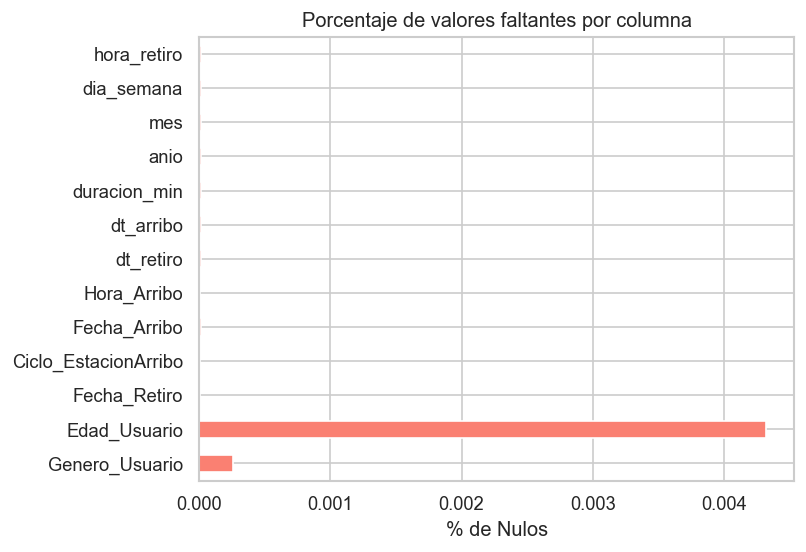

In [9]:
# Calcula el porcentaje de nulos por columna
null_counts = df.isnull().sum() / len(df) * 100

# Grafica solo las columnas que tienen nulos
null_counts[null_counts > 0].plot(kind='barh', color='salmon')
plt.title("Porcentaje de valores faltantes por columna")
plt.xlabel("% de Nulos")
plt.show()

In [10]:
pct_nulos = (df.isnull().mean() * 100).round(2)
print(pct_nulos[pct_nulos > 0].sort_values(ascending=False).to_string())

Series([], )


In [11]:
n_dup = df.duplicated().sum()
print(f"\nFilas duplicadas: {n_dup:,} ({n_dup/len(df)*100:.2f}%)")


Filas duplicadas: 0 (0.00%)


In [12]:
mask_bad = (df['duracion_min'] <= 0) | (df['duracion_min'] > 1440)
print(f"Duraciones fuera de rango: {mask_bad.sum():,}")

Duraciones fuera de rango: 1,181


## Análisis exploratorio

In [22]:
df_clean = df[
    (df['duracion_min'] > 0) &
    (df['duracion_min'] <= 180)  
].copy()

### Viajes por año

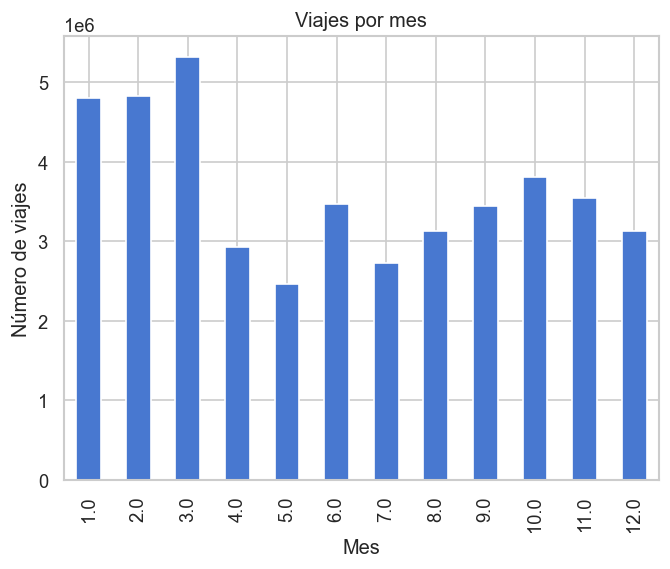

In [23]:
df_clean['mes'].value_counts().sort_index().plot.bar()
plt.title("Viajes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de viajes")
plt.show()

### Viajes por hora del día

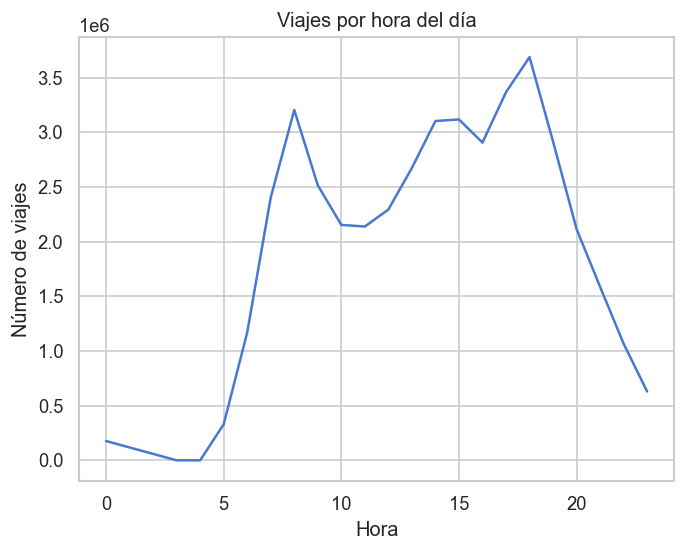

In [24]:
df_clean.groupby('hora_retiro').size().plot()
plt.title("Viajes por hora del día")
plt.xlabel("Hora")
plt.ylabel("Número de viajes")
plt.show()

### Distrinución de duración

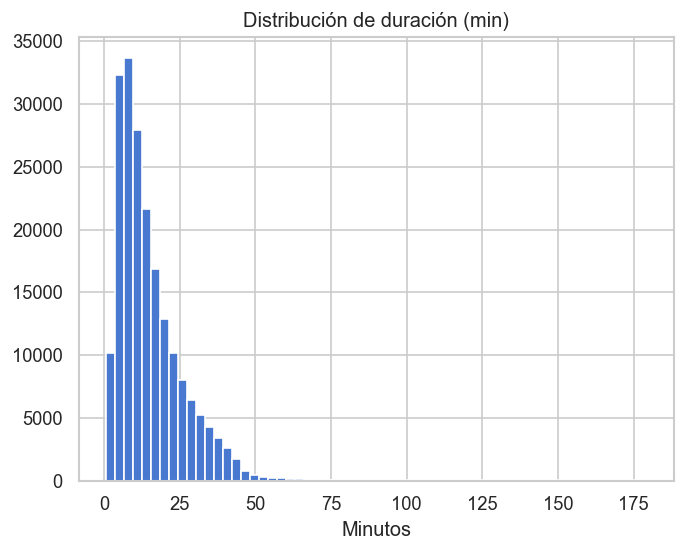

In [26]:
df_clean['duracion_min'].sample(200000).hist(bins=60)
plt.title("Distribución de duración (min)")
plt.xlabel("Minutos")
plt.show()

### Distribución de edad

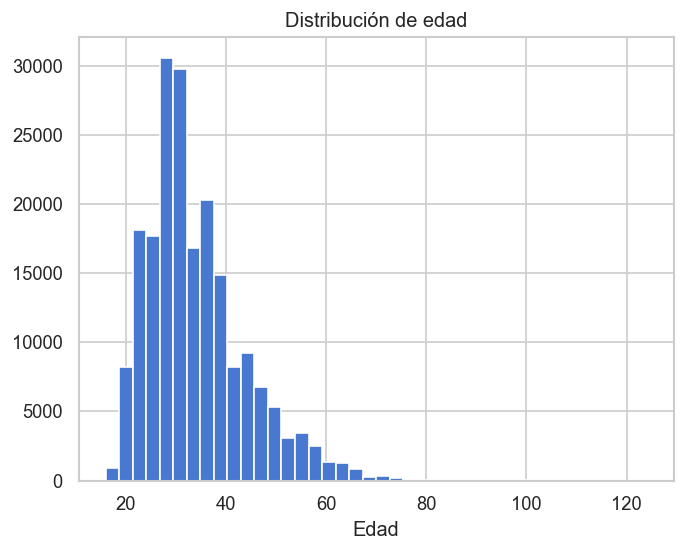

In [27]:
df_clean['Edad_Usuario'].dropna().sample(200000).hist(bins=40)
plt.title("Distribución de edad")
plt.xlabel("Edad")
plt.show()

### Viajes por día de la semana

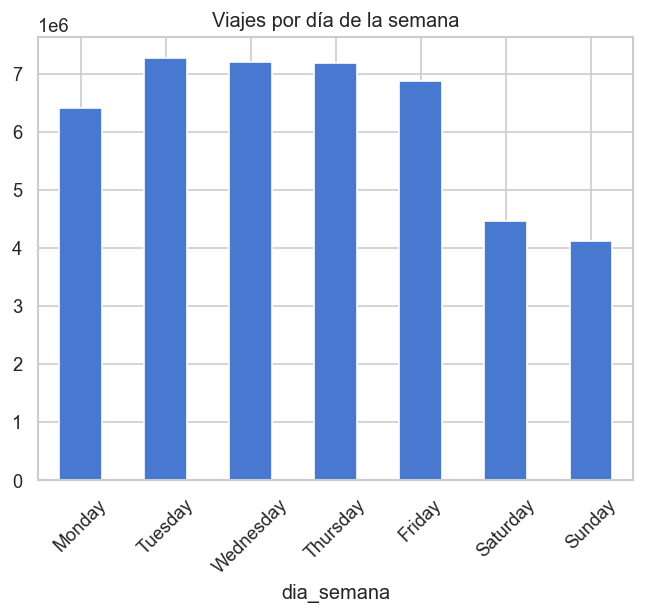

In [25]:
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df_clean['dia_semana'].value_counts().reindex(orden_dias).plot.bar()
plt.title("Viajes por día de la semana")
plt.xticks(rotation=45)
plt.show()

### Proporción de género

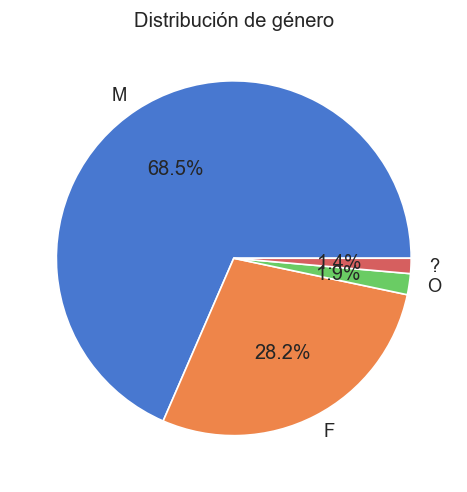

In [28]:
df_clean['Genero_Usuario'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Distribución de género")
plt.ylabel("")
plt.show()

### Hora vs día

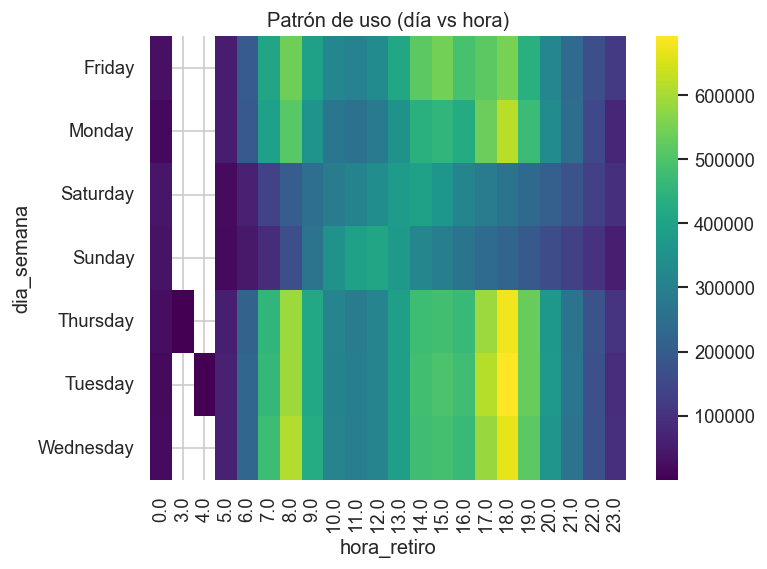

In [33]:
pivot = df_clean.groupby(['dia_semana','hora_retiro']).size().unstack()

import seaborn as sns
sns.heatmap(pivot, cmap="viridis")
plt.title("Patrón de uso (día vs hora)")
plt.show()

### Análisis de estaciones

#### Top 5 estaciones con más retiros

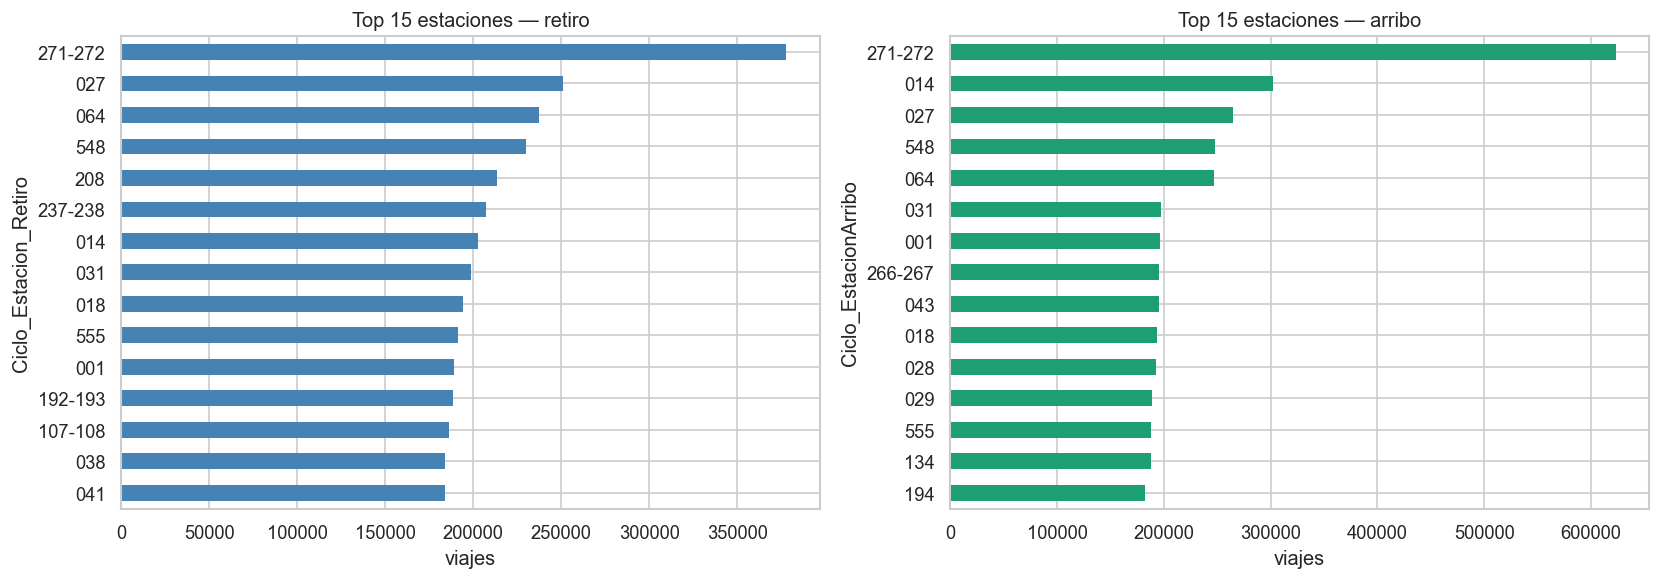

In [20]:
top_retiro = (
    df_clean['Ciclo_Estacion_Retiro']
    .value_counts()
    .head(15)
)

top_arribo = (
    df_clean['Ciclo_EstacionArribo']
    .value_counts()
    .head(15)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

top_retiro.plot.barh(ax=ax1, color='steelblue', edgecolor='none')
ax1.invert_yaxis()
ax1.set_title("Top 15 estaciones — retiro")
ax1.set_xlabel("viajes")

top_arribo.plot.barh(ax=ax2, color='#1D9E75', edgecolor='none')
ax2.invert_yaxis()
ax2.set_title("Top 15 estaciones — arribo")
ax2.set_xlabel("viajes")

plt.tight_layout()
plt.show()

#### Balance neto por estación

In [29]:
retiros = df_clean['Ciclo_Estacion_Retiro'].value_counts()
arribos = df_clean['Ciclo_EstacionArribo'].value_counts()
balance = (retiros - arribos).dropna().sort_values()

print("Estaciones con más SALIDAS netas (fuente):")
print(balance.tail(10))
print("\nEstaciones con más ENTRADAS netas (sumidero):")
print(balance.head(10))

Estaciones con más SALIDAS netas (fuente):
022        17639
494        17847
711        18606
465        18852
235-236    23624
495        24300
211        27062
192-193    34656
208        35163
237-238    52919
Name: count, dtype: int64

Estaciones con más ENTRADAS netas (sumidero):
271-272   -245133
014        -99397
266-267    -56372
043        -32419
273-274    -25694
029        -25008
217        -21957
260        -19781
134        -19085
548        -18229
Name: count, dtype: int64


### Correlaciones y selección de variables

#### Features númericas

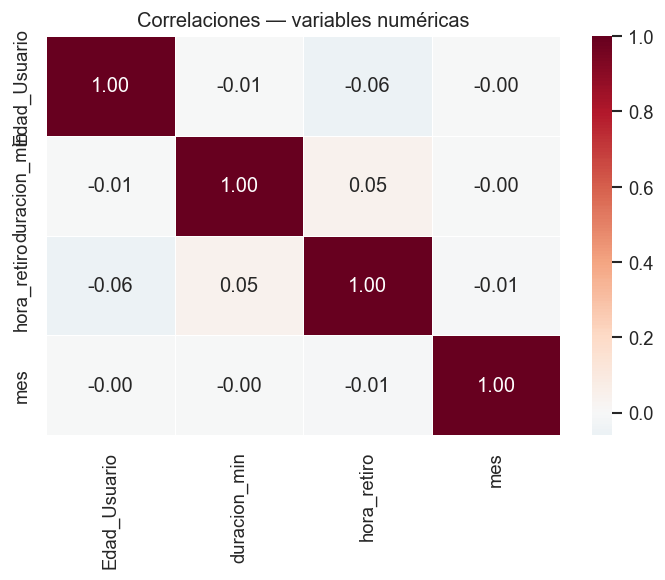

In [30]:
num_cols = ['Edad_Usuario', 'duracion_min', 'hora_retiro', 'mes']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    df_clean[num_cols].corr(),
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title("Correlaciones — variables numéricas")
plt.tight_layout()
plt.show()

#### Pairplot

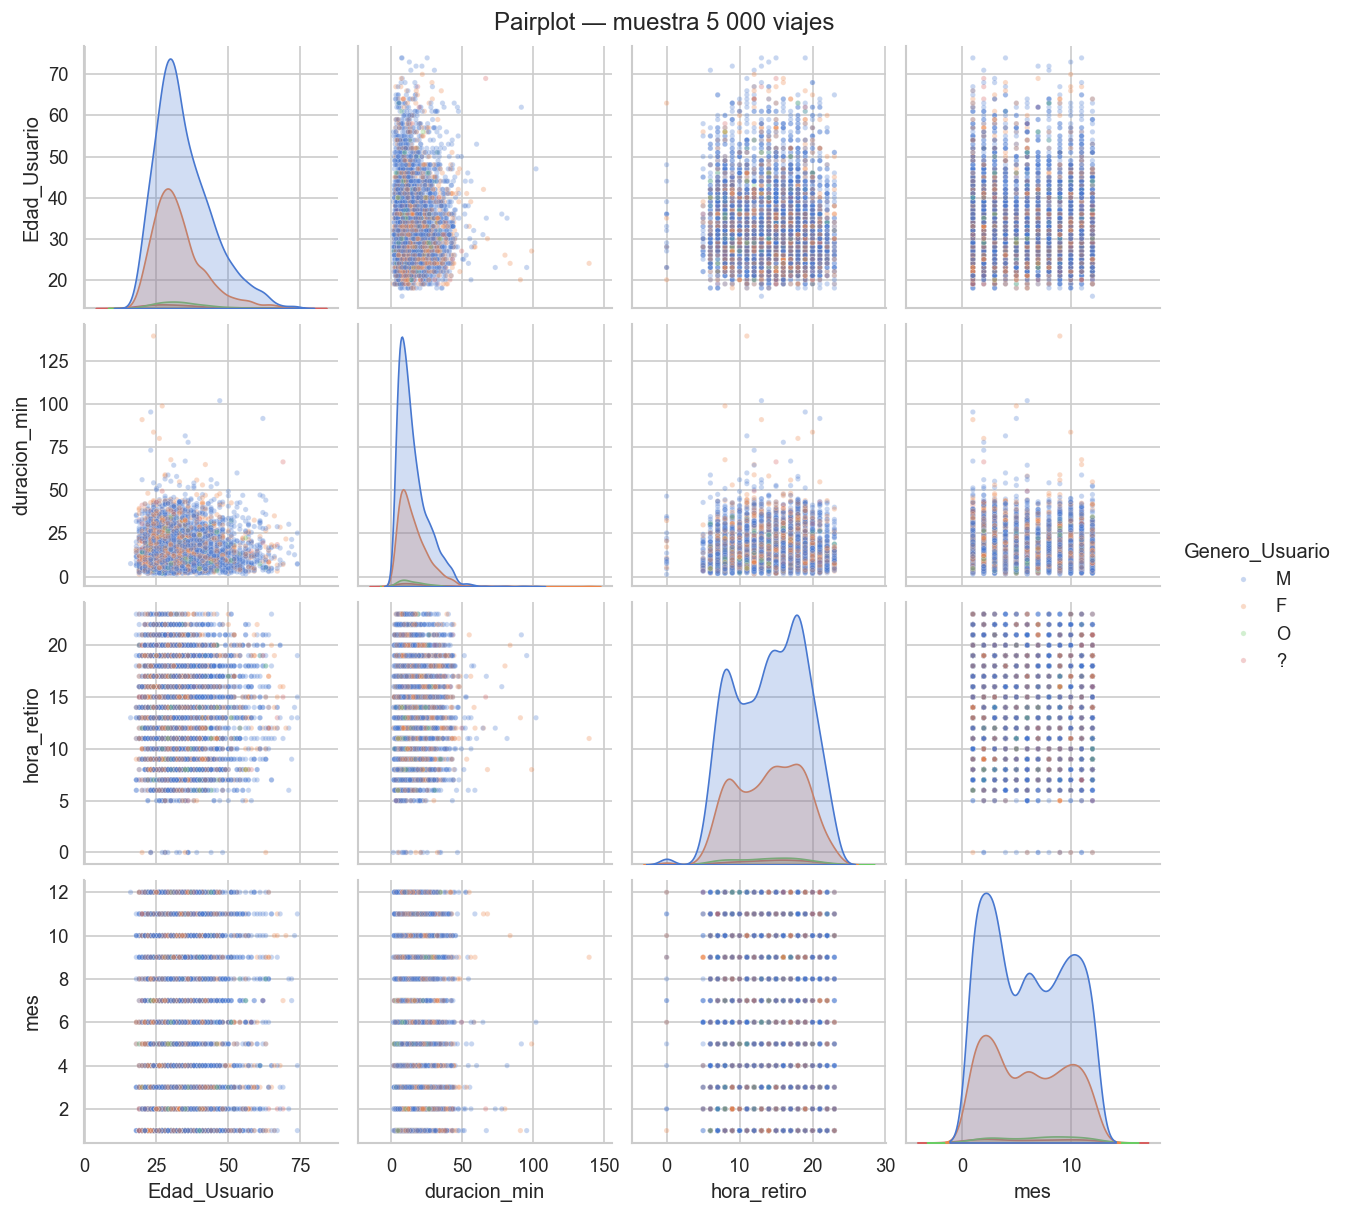

In [31]:
sample = df_clean[num_cols + ['Genero_Usuario']].dropna().sample(5000, random_state=42)
sns.pairplot(sample, hue='Genero_Usuario', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle("Pairplot — muestra 5 000 viajes", y=1.01)
plt.show()